# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [18]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_macro_stream_13.h5ad"
binarised_file= "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Binarisation_stream_13/Binarisation_scbolt/bin/consensus/cellrank/mstates_bin.csv"
binarized_file_output = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/data_binarized_stream_13.csv"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="timepoint" # stream2 or timepoint

In [49]:
import sys
#!pip install gseapy
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import gseapy as gp
from gseapy import get_library
from scipy.stats import fisher_exact
import json
import requests
from scipy.signal import argrelmin
from scipy.stats import gaussian_kde
import math
import time
import decoupler as dc
import matplotlib.patches as patches
import matplotlib as mpl
import textwrap
#! pip install goatools
#!pip install leidenalg

In [23]:
warnings.filterwarnings("ignore")
adata = sc.read(input_file) # read data 
# Delete cells with macrostates == "None"
adata = adata[adata.obs["macrostates"] != "None"].copy()

if adata.X.max() > 10 : # check if is raw data, need to be > 10
    # Normalization
    sc.pp.normalize_total(adata) # 
    sc.pp.log1p(adata)
    print("=== This dataset is now normalised")
else :
    print("=== This dataset appears to have already been normalised")

# Verify if we have only the cells expected and the macrostates 
print("=== Cell type and macrostates in our dataset")
print(adata.obs["Annotation"].unique())
print(adata.obs["macrostates"].unique())

=== This dataset appears to have already been normalised
=== Cell type and macrostates in our dataset
['B intermediate', 'B naive', 'B', 'Bridge']
Categories (4, object): ['B', 'B intermediate', 'B naive', 'Bridge']
['S3', 'S11', 'S0', 'S2']
Categories (4, object): ['S0', 'S2', 'S3', 'S11']


# 1) Separate Tfs and genes  

In [16]:
# TFs CollecTRI
net = dc.op.collectri(organism='human')
tf_list = net["source"].unique().tolist()

is_tf = adata.var_names.isin(tf_list)
# TFs object
adata_tf = adata[:, is_tf].copy()
# Genes object 
adata_genes = adata[:, ~is_tf].copy()

print(f"TFs     : {adata_tf.n_vars} features")
print(f"Genes  : {adata_genes.n_vars} features")

TFs     : 1180 features
Genes  : 17543 features


# 2) Genes : Binarization with scBoolSeq (scBolt)

In [60]:
binarized_states = pd.read_csv(binarised_file,index_col=0)
print(f"{binarized_states.columns} features")
binarized_states = binarized_states.dropna(axis=1, how="all")
print(f"{binarized_states.columns} features")
binarized_states.to_csv(binarized_file_output)

Index(['NOC2L', 'ISG15', 'C1orf159', 'TNFRSF18', 'TNFRSF4', 'SDF4', 'B3GALT6',
       'UBE2J2', 'PUSL1', 'INTS11',
       ...
       'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5',
       'MT-ND6', 'MT-CYB', 'MAFIP'],
      dtype='object', length=11072) features
Index(['TNFRSF18', 'TNFRSF4', 'ACOT7', 'PER3', 'ENO1', 'PIK3CD', 'PGD',
       'PEX14', 'SRM', 'MAD2L2',
       ...
       'SSR4', 'FLNA', 'GAB3', 'MPP1', 'MTCP1', 'RAB39B', 'TMLHE', 'IL9R',
       'ZFY', 'UTY'],
      dtype='object', length=2625) features


In [67]:
binarized_states.to_csv(binarized_file_output)

In [68]:
genes = ["NANOG", "CEBPA","CEBPB","CEBPD","SPI1","ETV6","BACH2"]
[g for g in genes if g in binarized_states.columns]

['PER3', 'CEBPB', 'CEBPD', 'SPI1', 'ETV6', 'BACH2']

# 3) Evaluate the features selection

Evaluate the gene selection. Important genes: genes DEG between B cells and bridge + TF DEG 

In [69]:
binarized_states[["CEBPD","IKZF2","SPI1","FOS","CEBPB"]]

,CEBPD,IKZF2,SPI1,FOS,CEBPB
macrostate,,,,,
S0,0.0,1.0,NaN,NaN,0.0
S11,NaN,NaN,NaN,NaN,0.0
S2,1.0,0.0,1.0,1.0,1.0
S3,NaN,NaN,0.0,0.0,1.0


In [62]:
# TFs expected (DEG TF activity between B cells and bridge) from SCENIC
TF=["CEBPD","CEBPA","ZNF333","ELF4","NFATC2","RFXAP","NANOG","LHX4","PAX7","ZNF250","IKZF2","HOXA5","ZFP92","SPI1",
 "FOSL2","OVOL3","ELF3","NFIX","FOS","TGIF1"]

# Genes expected by DEG 
adata.obs["celltype"] = np.where(
    adata.obs["Annotation"].isin(
        ["B intermediate", "B naive", "B memory", "B"]
    ),
    "B cells",
    adata.obs["Annotation"]
)
sc.tl.rank_genes_groups(adata,groupby="celltype",method="wilcoxon",reference="B cells",use_raw=False)
df = sc.get.rank_genes_groups_df(adata,group="Bridge")

# Filtering 
df_sig = df[
    (df["pvals_adj"] < 0.05) &
    (df["logfoldchanges"] > 0.5)
]

# Genes list DEG
genes = df_sig["names"].tolist()

# Genes list total
gene_list = list(set(genes + TF))

# Percentage of features expected in the binarised matrix 
present = [g for g in gene_list if g in binarized_states.columns]

percent_present = 100 * len(present) / len(gene_list)

print(f"{len(present)}/{len(gene_list)} genes present in binarised matrix")
print(f"{percent_present:.2f}%")

110/155 genes present in binarised matrix
70.97%


# 4) Evaluate the binarization per macrostates 

A- The genes by DEG should be 1, proportion of the DEG genes in the bridge that are active, should be 100%. 

In [63]:
row = binarized_states.loc["S2"]
genes_present = [g for g in gene_list if g in binarized_states.columns]
values = row[genes_present]
percent_active = 100 * (values == 1).sum() / len(values)

print(f"{percent_active:.2f}% genes active in macrostate bridge")

99.09% genes active in macrostate bridge


B- Look at pathways selected in the binarised matrix

S2: 99 genes up, 2683 genes down
S3: 807 genes up, 472 genes down
S0: 2051 genes up, 244 genes down
Enrichment for S2

Top 2 pathways for S2:
  - Inflammatory Response (GO:0006954) (adj p=1.73e-09)
  - Granulocyte Chemotaxis (GO:0071621) (adj p=6.36e-07)
Enrichment for S3

Top 2 pathways for S3:
  - Ribosome Biogenesis (GO:0042254) (adj p=4.76e-39)
  - Ribonucleoprotein Complex Biogenesis (GO:0022613) (adj p=2.46e-29)
Enrichment for S0

Top 2 pathways for S0:
  - Regulation of DNA-templated Transcription (GO:0006355) (adj p=9.50e-20)
  - Regulation of Transcription by RNA Polymerase II (GO:0006357) (adj p=1.99e-14)


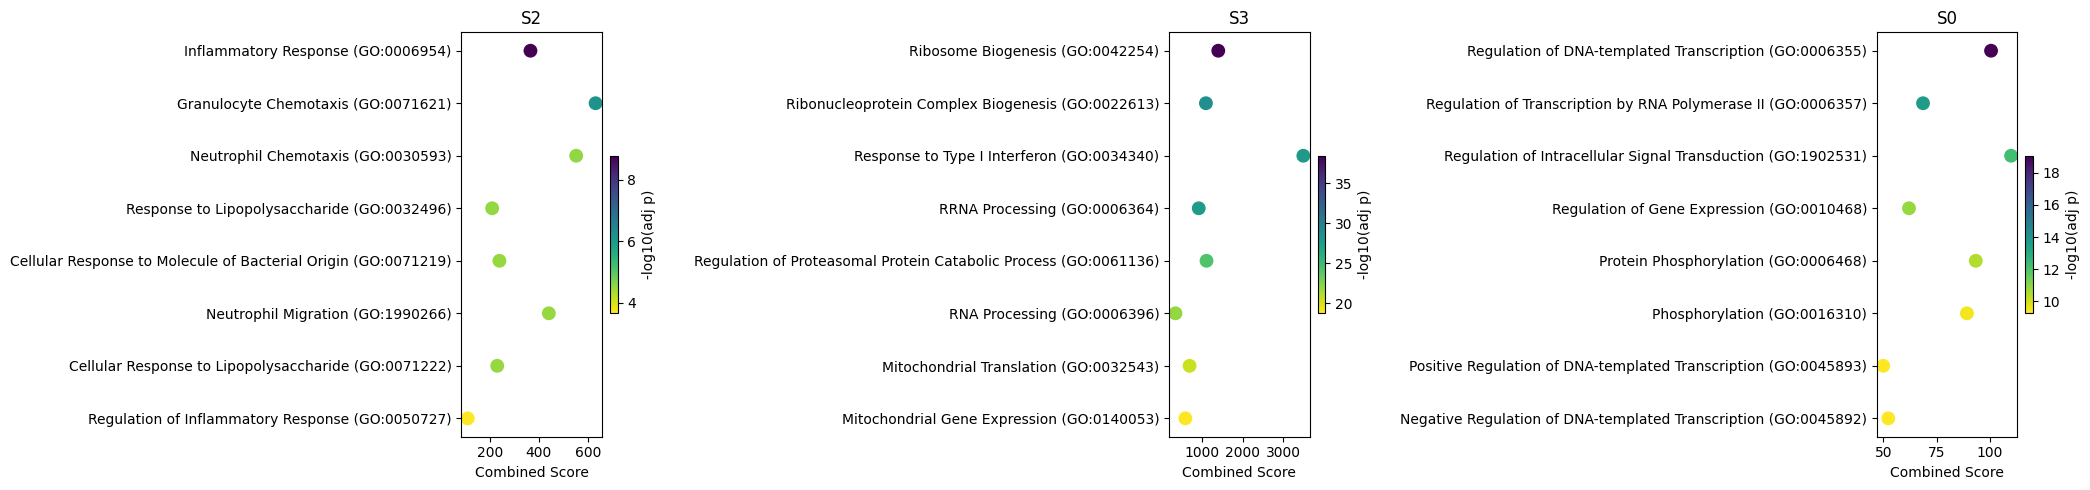

dict_keys(['Inflammatory Response', 'Granulocyte Chemotaxis', 'Ribosome Biogenesis', 'Ribonucleoprotein Complex Biogenesis', 'Regulation of DNA-templated Transcription', 'Regulation of Transcription by RNA Polymerase II'])


In [64]:
#adata_hvg = adata_no_none[:, adata_no_none.var["highly_variable"]]
adata_no_none = adata[adata.obs["macrostates"] != "S11"].copy()
macrostates=["S2", "S3","S0"]
# DEG per macrostates
#sc.tl.rank_genes_groups(adata_hvg,groupby="macrostates",groups=list(macrostates),reference="rest", use_raw=False,method="wilcoxon")
sc.tl.rank_genes_groups(adata_no_none,groupby="macrostates",groups=macrostates,reference="rest", use_raw=False,method="wilcoxon")


deg_lists_up = {}
deg_lists_down = {}

pval_thresh = 0.05
lfc_thresh = 1.0  # log fold change

for ct in macrostates:
    deg_df = sc.get.rank_genes_groups_df(adata_no_none, group=ct)
    up = deg_df[(deg_df["pvals_adj"] < pval_thresh) & (deg_df["logfoldchanges"] > lfc_thresh)]
    down = deg_df[(deg_df["pvals_adj"] < pval_thresh) & (deg_df["logfoldchanges"] < -lfc_thresh)]
    deg_lists_up[ct] = up["names"].tolist()
    deg_lists_down[ct] = down["names"].tolist()
    print(f"{ct}: {len(deg_lists_up[ct])} genes up, {len(deg_lists_down[ct])} genes down")

# Pathways enrichisment on up genes per macrostates
n = len(macrostates)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
axes = axes.flatten()

enrich_results = {}
top_terms_per_state = {}

for i, ct in enumerate(macrostates):
    print(f"Enrichment for {ct}")
    gene_list = deg_lists_up[ct]

    if len(gene_list) == 0:
        print(f"  No gene up regulated for {ct}, skip.")
        axes[i].axis("off")
        continue
    time.sleep(2)
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets="GO_Biological_Process_2026",
        organism="human",
        outdir=None
    )
    df = enr.results.copy()
    enrich_results[ct] = df

    if df.empty:
        print(f"  No enrichment result for {ct}, skip.")
        axes[i].axis("off")
        continue

    # Top pathways
    df_sorted = df.sort_values("Adjusted P-value")
    top2 = df_sorted.head(2)
    top_terms_per_state[ct] = top2["Term"].tolist()

    print(f"\nTop 2 pathways for {ct}:")
    for _, row in top2.iterrows():
        print(f"  - {row['Term']} (adj p={row['Adjusted P-value']:.2e})")

    df_plot = df.sort_values("Adjusted P-value").head(8).copy()
    df_plot["GeneRatio"] = df_plot["Overlap"].str.split("/").apply(lambda x: int(x[0]) / int(x[1]))

    scp = axes[i].scatter(
        x=df_plot["Combined Score"],
        y=df_plot["Term"],
        c=-np.log10(df_plot["Adjusted P-value"]),
        s=80, cmap="viridis_r"
    )
    axes[i].set_title(ct)
    axes[i].set_xlabel("Combined Score")
    axes[i].set_ylabel("")
    axes[i].invert_yaxis()

    # Colorbar
    cbar = fig.colorbar(scp, ax=axes[i], fraction=0.05)
    cbar.set_label("-log10(adj p)", fontsize=10)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(wspace=0.6, hspace=0.4)
plt.tight_layout()
fig.savefig(f"{output_directory}/GO_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

def get_pathways_dict():
    url = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2026"
    r = requests.get(url)
    pathways = {}
    for line in r.text.strip().split("\n"):
        parts = line.split("\t")
        if len(parts) > 2:
            pathways[parts[0]] = parts[2:]
    return pathways

pathway = get_pathways_dict()
pathways = {}
for ct, terms in top_terms_per_state.items():
    for term in terms:
        label = term.split(" (GO:")[0]
        if term in pathway:
            pathways[label] = pathway[term]
        else:
            print(f"WARNING : term '{term}' impossible to find in the database GO_Biological_Process_2026")

print(pathways.keys())

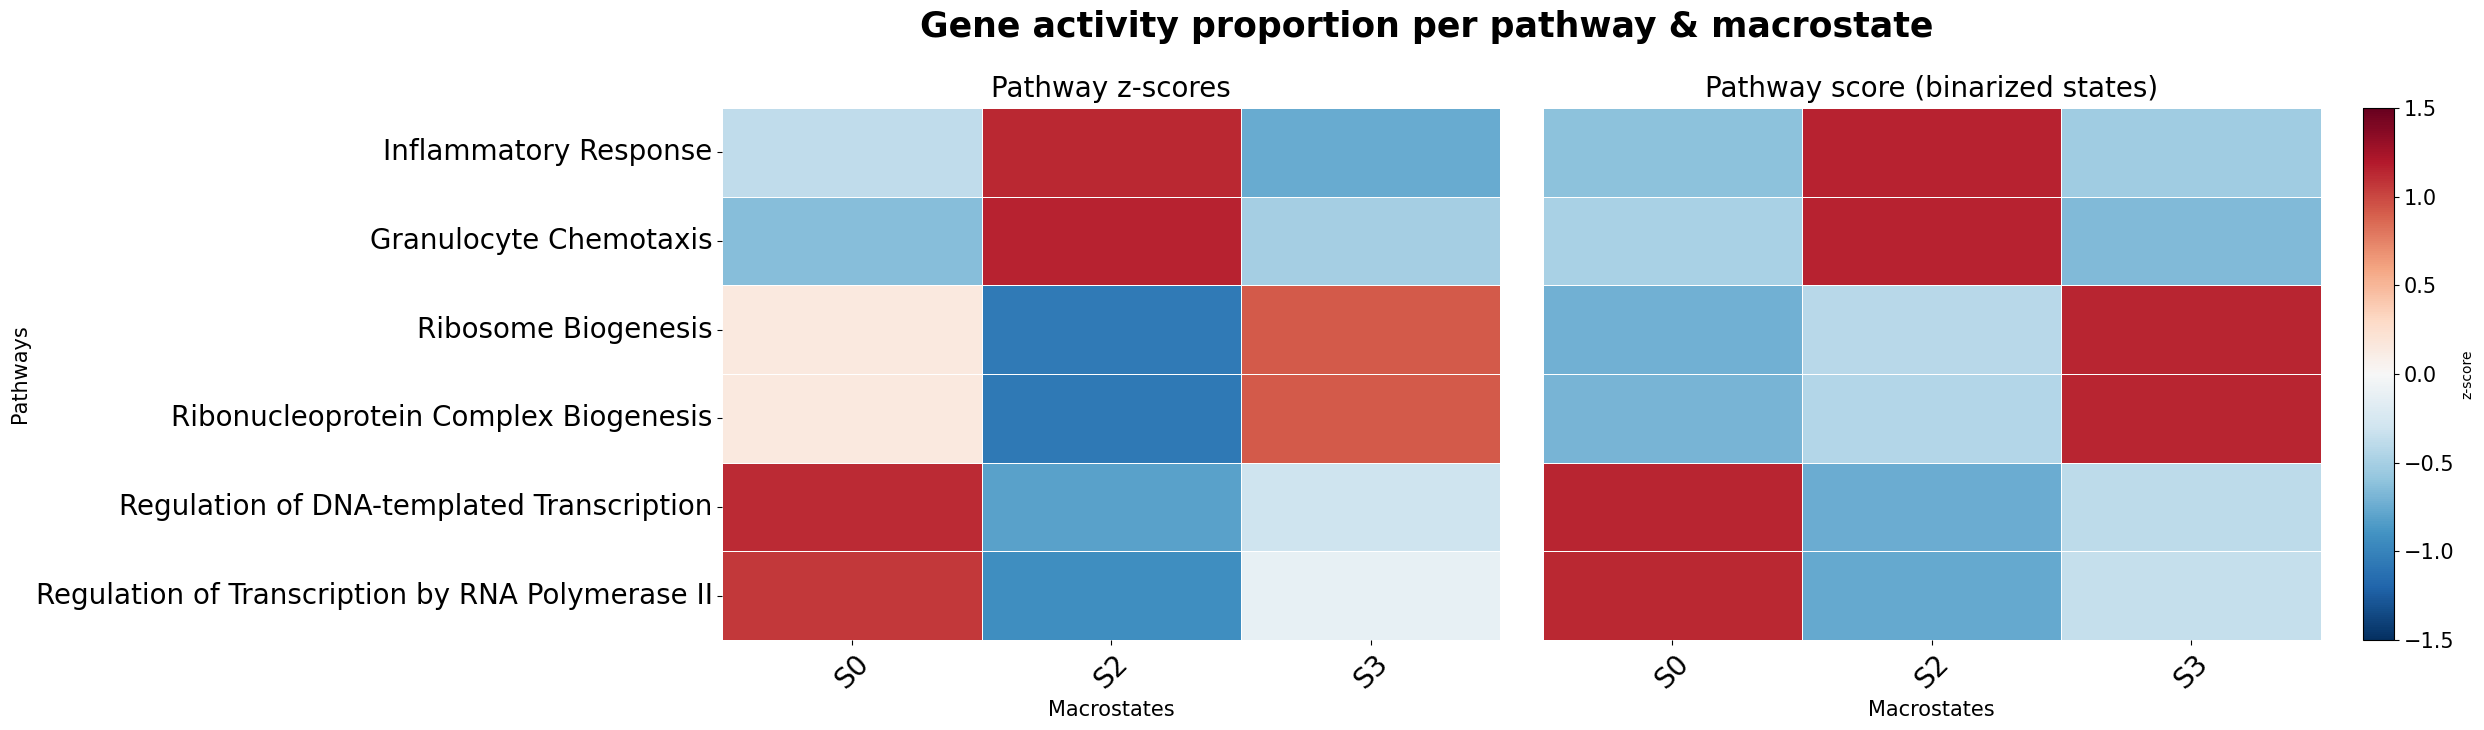

In [65]:
fig = plt.figure(figsize=(22, 7), constrained_layout=False)

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1, 1, 0.04],
    left=0.18, right=0.94,
    top=0.88, bottom=0.12,
    wspace=0.08
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

vmin, vmax = -1.5, 1.5
cmap = "RdBu_r"

# 1. HEATMAP
sns.heatmap(
    mean_scores_z_all.T,
    cmap=cmap,
    center=0,
    linewidths=0.5,
    cbar=False,
    vmin=vmin,
    vmax=vmax,
    yticklabels=True,
    ax=ax0
)
ax0.set_title("Pathway z-scores", fontsize=20, pad=8)
ax0.set_xlabel("Macrostates", fontsize=15)
ax0.set_ylabel("Pathways", fontsize=15)
ax0.tick_params(axis='y', labelsize=20)
ax0.tick_params(axis='x', labelsize=20, rotation=45)

# 2. HEATMAP : scores binarised
sns.heatmap(
    scores_df_z,
    cmap=cmap,
    annot=False,
    linewidths=0.5,
    center=0,
    vmin=vmin,
    vmax=vmax,
    cbar=False, 
    yticklabels=False,
    ax=ax1
)
ax1.set_title("Pathway score (binarized states)", fontsize=20, pad=8)
ax1.set_xlabel("Macrostates", fontsize=15)
ax1.set_ylabel("")
ax1.tick_params(axis='x', labelsize=20, rotation=45)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm   = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="z-score")
cax.tick_params(labelsize=15)

fig.suptitle("Gene activity proportion per pathway & macrostate",
             fontsize=25, fontweight="bold", y=1.02)

plt.savefig(
    f"{output_directory}/pathways_heatmaps_side_by_side.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

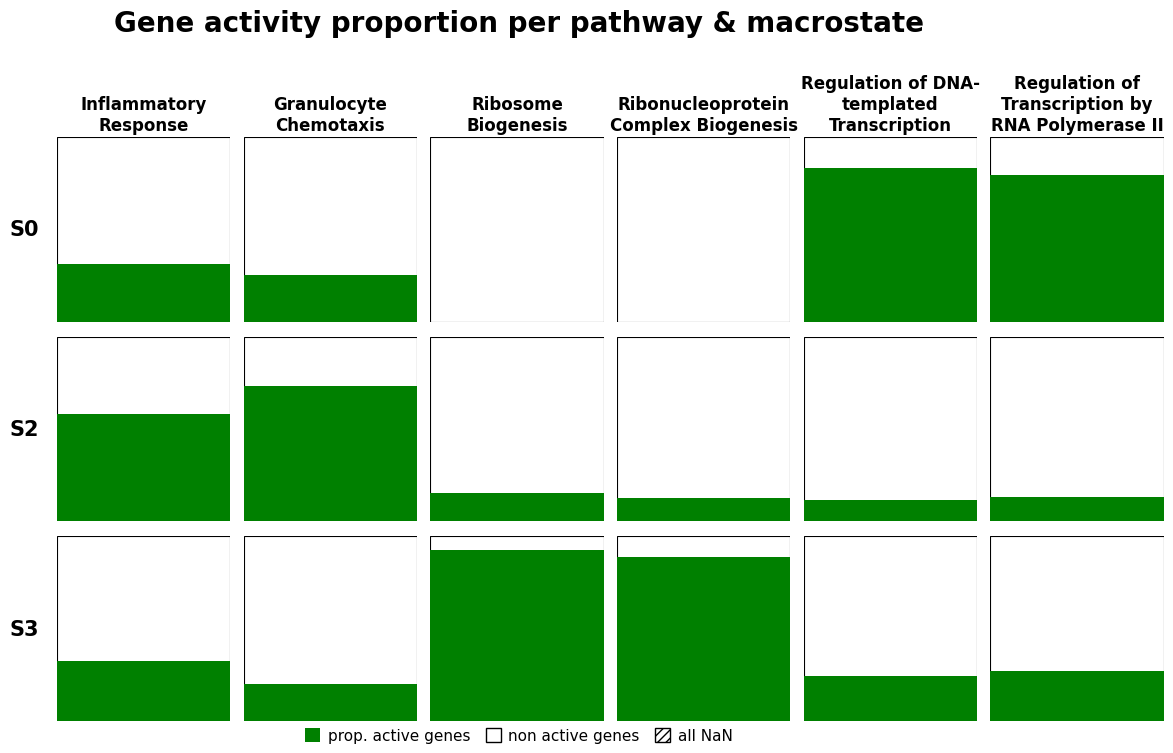

In [66]:
def plot_pathway_proportions(binarized_states, pathways, figsize_scale=(2.2, 2.4),
                             exclude_states=None):
    macrostates = [s for s in binarized_states.index
                   if exclude_states is None or s not in exclude_states]

    n_states   = len(macrostates)
    n_pathways = len(pathways)

    fig, axes = plt.subplots(
        n_states, n_pathways,  
        figsize=(n_pathways * figsize_scale[0], n_states * figsize_scale[1]),
        squeeze=False
    )

    for col, (pw_name, genes) in enumerate(pathways.items()): 
        for row, state in enumerate(macrostates):      
            ax = axes[row, col]
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis("off")

            pw_genes = [g for g in genes if g in binarized_states.columns]
            if not pw_genes:
                ax.add_patch(patches.Rectangle(
                    (0, 0), 1, 1, transform=ax.transAxes,
                    facecolor="lightgray", edgecolor="green", linewidth=0.8
                ))
                ax.text(0.5, 0.5, "no genes", ha="center", va="center",
                        color="gray", fontsize=7, transform=ax.transAxes)
            else:
                values = binarized_states.loc[state, pw_genes]
                valid  = values.dropna()
                ax.add_patch(patches.Rectangle(
                    (0, 0), 1, 1, transform=ax.transAxes,
                    facecolor="white", edgecolor="black", linewidth=0.8
                ))
                if len(valid) == 0:
                    ax.add_patch(patches.Rectangle(
                        (0, 0), 1, 1, transform=ax.transAxes,
                        facecolor="none", edgecolor="black", linewidth=0.8,
                        hatch="////"
                    ))
                else:
                    proportion = valid.sum() / len(valid)
                    if proportion > 0:
                        ax.add_patch(patches.Rectangle(
                            (0, 0), 1, proportion, transform=ax.transAxes,
                            facecolor="green", edgecolor="none"
                        ))

            # Header pathways
            if row == 0:
                wrapped = "\n".join(textwrap.wrap(pw_name, width=18))
                ax.set_title(wrapped, fontsize=12, pad=5, fontweight="bold")

            # Label macrostate
            if col == 0:
                ax.text(-0.1, 0.5, state,
                        fontsize=15, fontweight="bold",
                        rotation=0, va="center", ha="right",
                        transform=ax.transAxes)

    fig.suptitle("Gene activity proportion per pathway & macrostate",
                 fontsize=20, y=1.01, fontweight="bold")

    legend_elements = [
        patches.Patch(facecolor="green", label="prop. active genes"),
        patches.Patch(facecolor="white", edgecolor="black", label="non active genes"),
        patches.Patch(facecolor="none",  edgecolor="black", hatch="////", label="all NaN"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02),
               frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(left=0.15)
    plt.savefig(f"{output_directory}/pathway_proportions.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_pathway_proportions(binarized_states, pathways, exclude_states=["S11"])